# **Evaluar mediante Modelos de Regresión Lineal Múltiple la Relación entre el Año de Estudio y los Parámetros del Espermograma**

## **Librerías Importadas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## **Lectura de Datos**

In [2]:
df = pd.read_excel('datos.xlsx')

## **Delimitación Temporal de la Muestra**

Los registros disponibles abarcan desde 2017 hasta marzo de 2026; sin embargo, al contar únicamente con el primer trimestre de 2026, se opta por filtrar este año para mantener la consistencia del análisis, quedándonos con el período 2017–2025.

In [3]:
df = df[df['año'] != 26]
df = df.reset_index(drop=True)

## **Funciones**

### **Visualización de la Predicción Ajustada del Modelo**

Para representar gráficamente la relación entre el año de estudio y la variable de interés, controlando por los efectos de la edad y los días de abstinencia, se genera una gráfica de predicción ajustada a partir del modelo estadístico. La visualización muestra la línea de predicción principal junto con su intervalo de confianza del 95%, manteniendo las variables de control (edad y días de abstinencia) en sus valores medios. Esta representación permite observar la tendencia estimada de la variable a lo largo del tiempo, aislando el efecto de los factores de confusión incluidos en el modelo.

In [ ]:
def adjusted_prediction(model, data, var_name, color_borde="gray"):
    """Genera un gráfico de predicción ajustada a lo largo de los años manteniendo edad y dias_abstinencia en su media."""

    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        try:
            plt.style.use("seaborn-whitegrid")
        except OSError:
            plt.style.use("default")

    año_range = np.linspace(data["año"].min(), data["año"].max(), 100)

    X_pred = pd.DataFrame(
        {
            "año": año_range,
            "edad": data["edad"].mean(),
            "dias_abstinencia": data["dias_abstinencia"].mean(),
        }
    )

    pred = model.get_prediction(X_pred)
    pred_df = pred.summary_frame(alpha=0.05)

    if "mean_ci_lower" in pred_df.columns and "mean_ci_upper" in pred_df.columns:
        ci_lower_col = "mean_ci_lower"
        ci_upper_col = "mean_ci_upper"
    elif "ci_lower" in pred_df.columns and "ci_upper" in pred_df.columns:
        ci_lower_col = "ci_lower"
        ci_upper_col = "ci_upper"
    else:
        lower_cols = [c for c in pred_df.columns if c.endswith("_lower")]
        upper_cols = [c for c in pred_df.columns if c.endswith("_upper")]
        if lower_cols and upper_cols:
            ci_lower_col = lower_cols[0]
            ci_upper_col = upper_cols[0]
        else:
            raise ValueError(
                f"No se encontraron columnas de intervalo de confianza en: {list(pred_df.columns)}"
            )

    if "mean" in pred_df.columns:
        mean_col = "mean"
    elif "predicted_mean" in pred_df.columns:
        mean_col = "predicted_mean"
    else:
        numeric_cols = [
            c
            for c in pred_df.columns
            if c not in [ci_lower_col, ci_upper_col]
            and pred_df[c].dtype.kind in "ifc"
        ]
        if numeric_cols:
            mean_col = numeric_cols[0]
        else:
            raise ValueError(
                f"No se encontró columna de predicción media en: {list(pred_df.columns)}"
            )

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.grid(False)

    ax.fill_between(
        año_range,
        pred_df[ci_lower_col],
        pred_df[ci_upper_col],
        color="gray",
        alpha=0.3,
        linewidth=0,
    )

    ax.plot(
        año_range,
        pred_df[ci_lower_col],
        color=color_borde,
        linestyle="-",
        linewidth=0.8,
    )
    ax.plot(
        año_range,
        pred_df[ci_upper_col],
        color=color_borde,
        linestyle="-",
        linewidth=0.8,
    )

    ax.plot(año_range, pred_df[mean_col], color="black", linewidth=1.2)

    ax.set_xlabel("Año", fontweight="bold", labelpad=8)
    ax.set_ylabel(var_name, fontweight="bold", labelpad=8)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    return fig, ax

## **Modelo de Regresión Lineal Múltiple para el Volumen Seminal**

Para evaluar la relación entre el año de estudio y el volumen seminal, controlando por los posibles efectos de confusión de la edad del paciente y los días de abstinencia sexual previa, se ajusta un modelo de regresión lineal múltiple. El modelo incluye como variables predictoras el año de estudio, la edad y los días de abstinencia, y utiliza errores estándar robustos (HC3) para garantizar la validez de las inferencias en presencia de heterocedasticidad. A partir de los coeficientes estimados, se genera una gráfica de predicción ajustada que muestra la tendencia del volumen a lo largo del tiempo, manteniendo la edad y los días de abstinencia en sus valores medios, acompañada de su intervalo de confianza del 95%.

                            OLS Regression Results                            
Dep. Variable:             volumen_ml   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     36.21
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           5.01e-23
Time:                        17:10:28   Log-Likelihood:                -6075.8
No. Observations:                3384   AIC:                         1.216e+04
Df Residuals:                    3380   BIC:                         1.218e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.7012      0.234  

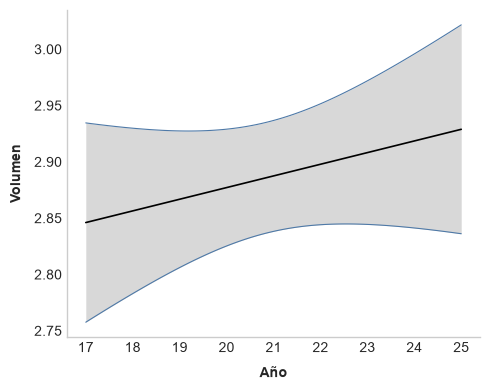

In [5]:
modelo_volumen = smf.ols(
    'volumen_ml ~ año + edad + dias_abstinencia',
    data=df
).fit(cov_type='HC3')

print(modelo_volumen.summary())

fig, ax = adjusted_prediction(
    model=modelo_volumen, 
    data=df, 
    var_name='Volumen', color_borde='#4E79A7'
)

**Resumen General**

El modelo de regresión lineal múltiple para el volumen seminal explica solo el 3.2% de la variabilidad del volumen (R² = 0.032), lo que indica que las variables incluidas (año, edad y días de abstinencia) tienen un poder predictivo muy limitado sobre el volumen seminal. El modelo es estadísticamente significativo en su conjunto (p < 0.001), pero la magnitud del efecto es muy pequeña. La edad y los días de abstinencia son predictores significativos del volumen, mientras que el año no lo es (p = 0.286).

**Evaluación Global del Modelo**

| Estadístico | Valor | Interpretación |
|-------------|-------|----------------|
| R² | 0.032 | Solo el 3.2% de la variabilidad del volumen es explicada por el modelo |
| R² Ajustado | 0.031 | Prácticamente igual al R², indica que las variables incluidas son relevantes |
| F-estadístico | 36.21 | Modelo significativo en su conjunto |
| p-value (F) | 5.01e-23 | Altamente significativo (p < 0.001) |
| n | 3,384 | Tamaño muestral adecuado |

- El modelo es estadísticamente significativo, pero clínicamente muy débil
- El 96.8% de la variabilidad del volumen queda sin explicar por estas variables


**Coeficientes del Modelo**

| Variable | Coeficiente | Error Estándar | z | p-value | IC 95% |
|----------|-------------|----------------|---|---------|--------|
| Intercepto | 3.7012 | 0.234 | 15.824 | < 0.001 | [3.243, 4.160] |
| Año | 0.0104 | 0.010 | 1.066 | 0.286 | [-0.009, 0.029] |
| Edad | -0.0329 | 0.003 | -10.068 | < 0.001 | [-0.039, -0.026] |
| Días de Abstinencia | 0.0511 | 0.019 | 2.715 | 0.007 | [0.014, 0.088] |

**Año (p = 0.286) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.0104 ml por año |
| p-value | 0.286 (no significativo) |
| IC 95% | [-0.009, 0.029] (incluye el cero) |
| Conclusión | No hay evidencia de que el volumen haya cambiado con el tiempo |

- El volumen no ha mostrado una tendencia significativa a lo largo del tiempo
- Este resultado es consistente con los análisis previos que no encontraron diferencias entre períodos

**Edad (p < 0.001) - Altamente significativa**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.0329 ml por año de edad |
| p-value | < 0.001 (altamente significativo) |
| IC 95% | [-0.039, -0.026] (no incluye el cero) |
| Conclusión | La edad tiene un efecto significativo sobre el volumen |

- Por cada año de edad, el volumen disminuye en 0.033 ml
- Un paciente de 40 años tendría, en promedio, 0.5 ml menos que uno de 25 años (15 años × 0.033 ml = 0.5 ml)
- La edad es el predictor más fuerte del volumen en este modelo

**Días de Abstinencia (p = 0.007) - Significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.0511 ml por día de abstinencia |
| p-value | 0.007 (significativo) |
| IC 95% | [0.014, 0.088] (no incluye el cero) |
| Conclusión | Los días de abstinencia tienen un efecto significativo sobre el volumen |

- Por cada día adicional de abstinencia, el volumen aumenta en 0.051 ml
- Un paciente con 5 días de abstinencia tendría, en promedio, 0.20 ml más que uno con 1 día de abstinencia (4 días × 0.051 ml = 0.20 ml)
- Este efecto es biológicamente plausible (mayor acumulación de líquido seminal)

**Evaluación de Supuestos del Modelo**

| Prueba | Estadístico | Valor | Interpretación |
|--------|-------------|-------|----------------|
| Omnibus | 631.17 | p < 0.001 | Los residuos no son normales |
| Jarque-Bera | 1460.21 | p < 0.001 | Los residuos no son normales |
| Skew | 1.050 | - | Asimetría positiva en los residuos |
| Kurtosis | 5.438 | - | Distribución más apuntada que la normal |
| Durbin-Watson | 1.720 | - | No hay autocorrelación (valor cercano a 2) |

**Interpretación de los supuestos**

| Supuesto | Estado | Interpretación |
|----------|--------|----------------|
| Normalidad de residuos | No se cumple | Los residuos no siguen una distribución normal |
| Homocedasticidad | Manejada | Se usaron errores robustos HC3 |
| Independencia | Cumplida | Durbin-Watson ≈ 1.72 (sin evidencia fuerte de autocorrelación) |
| Linealidad | Asumida | No se evaluó formalmente |

- La falta de normalidad de los residuos no afecta la validez de los coeficientes debido al uso de errores robustos (HC3)
- El modelo es robusto a la heterocedasticidad

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Modelo global | Significativo (p < 5.01e-23) pero muy débil (R² = 0.032) |
| Año | No significativo (p = 0.286) |
| Edad | Altamente significativa (p < 0.001) - disminuye el volumen |
| Días de abstinencia | Significativo (p = 0.007) - aumenta el volumen |
| Poder explicativo | Muy bajo - solo el 3.2% de la variabilidad explicada |

Conclusión Final

El modelo de regresión para el volumen seminal muestra que la edad y los días de abstinencia son predictores significativos, pero el año no lo es. La edad tiene un efecto negativo sobre el volumen (-0.033 ml por año), mientras que los días de abstinencia tienen un efecto positivo (+0.051 ml por día). Sin embargo, el poder explicativo del modelo es muy bajo (R² = 0.032), lo que indica que factores no incluidos en el modelo explican la mayor parte de la variabilidad del volumen seminal. No hay evidencia de un cambio significativo en el volumen a lo largo del tiempo después de controlar por edad y días de abstinencia.

## **Modelo de Regresión Lineal Múltiple para el pH Seminal**

Para evaluar la relación entre el año de estudio y el pH seminal, controlando por los posibles efectos de confusión de la edad del paciente y los días de abstinencia sexual previa, se ajusta un modelo de regresión lineal múltiple. El modelo incluye como variables predictoras el año de estudio, la edad y los días de abstinencia, y utiliza errores estándar robustos (HC3) para garantizar la validez de las inferencias en presencia de heterocedasticidad. A partir de los coeficientes estimados, se genera una gráfica de predicción ajustada que muestra la tendencia del pH a lo largo del tiempo, manteniendo la edad y los días de abstinencia en sus valores medios, acompañada de su intervalo de confianza del 95%.

                            OLS Regression Results                            
Dep. Variable:                     ph   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     4.647
Date:                Fri, 31 Jul 2026   Prob (F-statistic):            0.00303
Time:                        17:10:28   Log-Likelihood:                -171.41
No. Observations:                2896   AIC:                             350.8
Df Residuals:                    2892   BIC:                             374.7
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            7.7781      0.048  

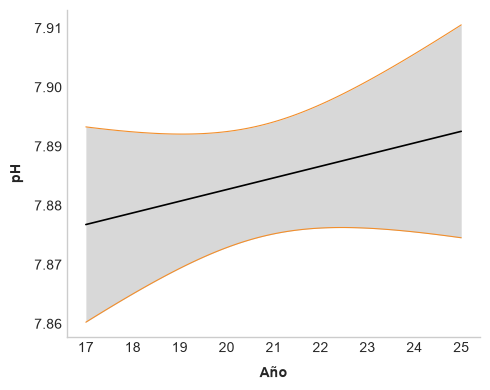

In [6]:
modelo_ph = smf.ols(
    'ph ~ año + edad + dias_abstinencia',
    data=df
).fit(cov_type='HC3')

print(modelo_ph.summary())

fig, ax = adjusted_prediction(
    model=modelo_ph, 
    data=df, 
    var_name='pH', color_borde='#F28E2B'
)

**Resumen General**

El modelo de regresión lineal múltiple para el pH seminal explica solo el 0.8% de la variabilidad del pH (R² = 0.008), lo que indica que las variables incluidas (año, edad y días de abstinencia) tienen un poder predictivo prácticamente nulo sobre el pH seminal. El modelo es significativo en su conjunto (p = 0.00303), aunque con un efecto muy pequeño. La edad es el único predictor significativo (p = 0.001), con un efecto muy pequeño, mientras que el año (p = 0.285) y los días de abstinencia (p = 0.098) no son significativos.

**Evaluación Global del Modelo**

| Estadístico | Valor | Interpretación |
|-------------|-------|----------------|
| R² | 0.008 | Solo el 0.8% de la variabilidad del pH es explicada por el modelo |
| R² Ajustado | 0.007 | Prácticamente igual al R², indica que las variables tienen poco poder predictivo |
| F-estadístico | 4.647 | Modelo significativo en su conjunto |
| p-value (F) | 0.00303 | Significativo (p < 0.01) |
| n | 2,896 | Tamaño muestral adecuado |

- El modelo es estadísticamente significativo al nivel convencional de 0.05
- El 99.2% de la variabilidad del pH queda sin explicar por estas variables
- El pH es un parámetro muy estable que no se ve afectado por estas variables

**Coeficientes del Modelo**

| Variable | Coeficiente | Error Estándar | z | p-value | IC 95% |
|----------|-------------|----------------|---|---------|--------|
| Intercepto | 7.7781 | 0.048 | 163.327 | < 0.001 | [7.685, 7.871] |
| Año | 0.0020 | 0.002 | 1.069 | 0.285 | [-0.002, 0.007] |
| Edad | 0.0025 | 0.001 | 3.219 | 0.001 | [0.001, 0.004] |
| Días de Abstinencia | -0.0070 | 0.004 | -1.655 | 0.098 | [-0.015, 0.001] |

**Año (p = 0.285) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.0020 unidades de pH por año |
| p-value | 0.285 (no significativo) |
| IC 95% | [-0.002, 0.007] (incluye el cero) |
| Conclusión | No hay evidencia de que el pH haya cambiado con el tiempo |

- El pH no ha mostrado una tendencia significativa a lo largo del tiempo
- Este resultado es consistente con la estabilidad del pH observada en todos los análisis

**Edad (p = 0.001) - Significativa**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.0025 unidades de pH por año de edad |
| p-value | 0.001 (significativo) |
| IC 95% | [0.001, 0.004] (no incluye el cero) |
| Conclusión | La edad tiene un efecto significativo sobre el pH, pero muy pequeño |

- Por cada año de edad, el pH aumenta en 0.003 unidades
- Un paciente de 40 años tendría, en promedio, 0.04 unidades más que uno de 25 años (15 años × 0.003 = 0.04)
- El efecto es biológicamente insignificante aunque estadísticamente significativo

**Días de Abstinencia (p = 0.098) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.0070 unidades de pH por día |
| p-value | 0.098 (no significativo) |
| IC 95% | [-0.015, 0.001] (incluye el cero) |
| Conclusión | No hay evidencia de que los días de abstinencia afecten el pH |

- Los días de abstinencia no tienen un efecto significativo sobre el pH
- Esto es consistente con la estabilidad del pH

**Evaluación de Supuestos del Modelo**

| Prueba | Estadístico | Valor | Interpretación |
|--------|-------------|-------|----------------|
| Omnibus | 556.77 | p < 0.001 | Los residuos no son normales |
| Jarque-Bera | 2461.26 | p < 0.001 | Los residuos no son normales |
| Skew | -0.865 | - | Asimetría negativa en los residuos |
| Kurtosis | 7.172 | - | Distribución más apuntada que la normal |
| Durbin-Watson | 1.883 | - | No hay autocorrelación (cercano a 2) |

**Interpretación de los supuestos:**

| Supuesto | Estado | Interpretación |
|----------|--------|----------------|
| Normalidad de residuos | No se cumple | Los residuos no siguen una distribución normal |
| Homocedasticidad | Manejada | Se usaron errores robustos HC3 |
| Independencia | Cumplida | Durbin-Watson ≈ 1.88 (no autocorrelación) |
| Linealidad | Asumida | No se evaluó formalmente |

- La falta de normalidad de los residuos se debe a la presencia de outliers (pH 2.0 y 3.0)
- El uso de errores robustos (HC3) mitiga este problema

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Modelo global | Significativo (p = 0.00303) |
| Año | No significativo (p = 0.285) |
| Edad | Significativa (p = 0.001) - aumenta el pH (muy poco) |
| Días de abstinencia | No significativo (p = 0.098) |
| Poder explicativo | Muy bajo (R² = 0.008) |

**Conclusión Final**

El modelo de regresión para el pH seminal es significativo (p = 0.00303) y tiene un poder predictivo muy bajo (R² = 0.008). La edad muestra un efecto significativo pero clínicamente irrelevante (+0.003 unidades por año). El año y los días de abstinencia no son predictores significativos. El pH es el parámetro más estable del espermograma, y estas variables no ayudan a explicar su variabilidad.

## **Modelo de Regresión Lineal Múltiple para el Recuento Total de Espermatozoides por Eyaculado**

Para evaluar la relación entre el año de estudio y el número total de espermatozoides por eyaculado, controlando por los posibles efectos de confusión de la edad del paciente y los días de abstinencia sexual previa, se ajusta un modelo de regresión lineal múltiple. El modelo incluye como variables predictoras el año de estudio, la edad y los días de abstinencia, y utiliza errores estándar robustos (HC3) para garantizar la validez de las inferencias en presencia de heterocedasticidad. A partir de los coeficientes estimados, se genera una gráfica de predicción ajustada que muestra la tendencia del recuento total a lo largo del tiempo, manteniendo la edad y los días de abstinencia en sus valores medios, acompañada de su intervalo de confianza del 95%.

                                  OLS Regression Results                                 
Dep. Variable:     espermatozoides_por_eyaculado   R-squared:                       0.033
Model:                                       OLS   Adj. R-squared:                  0.032
Method:                            Least Squares   F-statistic:                     31.93
Date:                           Fri, 31 Jul 2026   Prob (F-statistic):           2.40e-20
Time:                                   17:10:28   Log-Likelihood:                -68125.
No. Observations:                           3385   AIC:                         1.363e+05
Df Residuals:                               3381   BIC:                         1.363e+05
Df Model:                                      3                                         
Covariance Type:                             HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
---------------

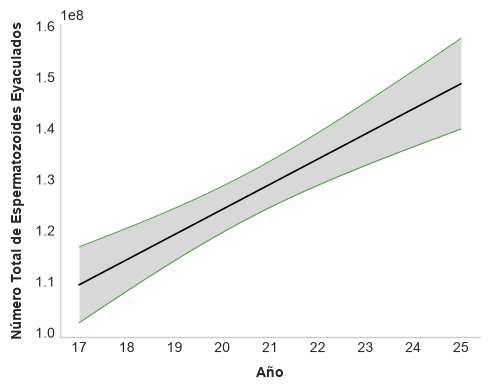

In [7]:
modelo_espermatozoides = smf.ols(
    'espermatozoides_por_eyaculado ~ año + edad + dias_abstinencia',
    data=df
).fit(cov_type='HC3')

print(modelo_espermatozoides.summary())

fig, ax = adjusted_prediction(
    model=modelo_espermatozoides, 
    data=df, 
    var_name='Número Total de Espermatozoides Eyaculados', color_borde='#59A14F'
)

**Resumen General**

El modelo de regresión lineal múltiple para el recuento total de espermatozoides por eyaculado explica el 3.3% de la variabilidad (R² = 0.033), lo que indica que las variables incluidas (año, edad y días de abstinencia) tienen un poder predictivo limitado sobre el recuento total. El modelo es altamente significativo en su conjunto (p < 2.40e-20). Las tres variables predictoras son significativas: el año y los días de abstinencia tienen un efecto positivo, mientras que la edad tiene un efecto negativo sobre el recuento total.

**Evaluación Global del Modelo**

| Estadístico | Valor | Interpretación |
|-------------|-------|----------------|
| R² | 0.033 | Solo el 3.3% de la variabilidad del recuento total es explicada por el modelo |
| R² Ajustado | 0.032 | Prácticamente igual al R², indica que las variables incluidas son relevantes |
| F-estadístico | 31.93 | Modelo significativo en su conjunto |
| p-value (F) | 2.40e-20 | Altamente significativo (p < 0.001) |
| n | 3,385 | Tamaño muestral adecuado |

- El modelo es estadísticamente significativo, pero clínicamente débil
- El 96.7% de la variabilidad del recuento total queda sin explicar por estas variables
- Otros factores no incluidos tienen un impacto mucho mayor

**Coeficientes del Modelo**

| Variable | Coeficiente | Error Estándar | z | p-value | IC 95% |
|----------|-------------|----------------|---|---------|--------|
| Intercepto | 85,600,000 | 22,400,000 | 3.824 | < 0.001 | [41,700,000, 129,000,000] |
| Año | +4,921,000 | 869,000 | 5.659 | < 0.001 | [3,220,000, 6,620,000] |
| Edad | -2,284,000 | 293,000 | -7.798 | < 0.001 | [-2,860,000, -1,710,000] |
| Días de Abstinencia | +6,438,000 | 2,280,000 | 2.827 | 0.005 | [1,970,000, 10,900,000] |

**Año (p < 0.001) - Altamente significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +4.92 millones por año |
| p-value | < 0.001 (altamente significativo) |
| IC 95% | [3.22M, 6.62M] (no incluye el cero) |
| Conclusión | El recuento total ha aumentado significativamente con el tiempo |

- Por cada año, el recuento total aumenta en 4.92 millones de espermatozoides
- Este resultado es consistente con el aumento observado en los análisis descriptivos (+18.5%)

**Edad (p < 0.001) - Altamente significativa**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -2.28 millones por año de edad |
| p-value | < 0.001 (altamente significativo) |
| IC 95% | [-2.86M, -1.71M] (no incluye el cero) |
| Conclusión | La edad tiene un efecto negativo sobre el recuento total |

- Por cada año de edad, el recuento total disminuye en 2.28 millones
- Un paciente de 40 años tendría, en promedio, 34.2 millones menos que uno de 25 años (15 años × 2.28M = 34.2M)
- Este efecto es biológicamente plausible (disminución de la producción espermática con la edad)

**Días de Abstinencia (p = 0.005) - Significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +6.44 millones por día de abstinencia |
| p-value | 0.005 (significativo) |
| IC 95% | [1.97M, 10.9M] (no incluye el cero) |
| Conclusión | Los días de abstinencia tienen un efecto positivo sobre el recuento total |

- Por cada día adicional de abstinencia, el recuento total aumenta en 6.44 millones
- Un paciente con 5 días de abstinencia tendría, en promedio, 25.8 millones más que uno con 1 día (4 días × 6.44M = 25.8M)
- Este efecto es biológicamente plausible (mayor acumulación de espermatozoides)

**Evaluación de Supuestos del Modelo**

| Prueba | Estadístico | Valor | Interpretación |
|--------|-------------|-------|----------------|
| Omnibus | 1390.93 | p < 0.001 | Los residuos no son normales |
| Jarque-Bera | 8228.65 | p < 0.001 | Los residuos no son normales |
| Skew | 1.862 | - | Asimetría positiva en los residuos |
| Kurtosis | 9.669 | - | Distribución más apuntada que la normal |
| Durbin-Watson | 1.752 | - | No hay autocorrelación (cercano a 2) |

**Interpretación de los supuestos**

| Supuesto | Estado | Interpretación |
|----------|--------|----------------|
| Normalidad de residuos | No se cumple | Los residuos no siguen una distribución normal |
| Homocedasticidad | Manejada | Se usaron errores robustos HC3 |
| Independencia | Cumplida | Durbin-Watson ≈ 1.75 (no autocorrelación) |
| Linealidad | Asumida | No se evaluó formalmente |

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Modelo global | Altamente significativo (p < 2.40e-20) pero muy débil (R² = 0.033) |
| Año | Altamente significativo (p < 0.001) - aumenta el recuento |
| Edad | Altamente significativa (p < 0.001) - disminuye el recuento |
| Días de abstinencia | Significativo (p = 0.005) - aumenta el recuento |
| Poder explicativo | Muy bajo - solo el 3.3% de la variabilidad explicada |

**Conclusión Final**

El modelo de regresión para el recuento total de espermatozoides por eyaculado muestra que el año, la edad y los días de abstinencia son predictores significativos. El año tiene un efecto positivo (+4.92M por año), la edad tiene un efecto negativo (-2.28M por año), y los días de abstinencia tienen un efecto positivo (+6.44M por día). Sin embargo, el poder explicativo del modelo es muy bajo (R² = 0.033), lo que indica que factores no incluidos en el modelo explican la mayor parte de la variabilidad del recuento total. El aumento en el recuento total a lo largo del tiempo (+39.4M entre 2017 y 2025) es consistente con los hallazgos descriptivos previos.

## **Modelo de Regresión Lineal Múltiple para la Concentración Espermática por ml**

Para evaluar la relación entre el año de estudio y la concentración de espermatozoides por mililitro, controlando por los posibles efectos de confusión de la edad del paciente y los días de abstinencia sexual previa, se ajusta un modelo de regresión lineal múltiple. El modelo incluye como variables predictoras el año de estudio, la edad y los días de abstinencia, y utiliza errores estándar robustos (HC3) para garantizar la validez de las inferencias en presencia de heterocedasticidad. A partir de los coeficientes estimados, se genera una gráfica de predicción ajustada que muestra la tendencia de la concentración a lo largo del tiempo, manteniendo la edad y los días de abstinencia en sus valores medios, acompañada de su intervalo de confianza del 95%.

                             OLS Regression Results                             
Dep. Variable:     concentracion_por_ml   R-squared:                       0.015
Model:                              OLS   Adj. R-squared:                  0.014
Method:                   Least Squares   F-statistic:                     16.47
Date:                  Fri, 31 Jul 2026   Prob (F-statistic):           1.26e-10
Time:                          17:10:28   Log-Likelihood:                -64219.
No. Observations:                  3385   AIC:                         1.284e+05
Df Residuals:                      3381   BIC:                         1.285e+05
Df Model:                             3                                         
Covariance Type:                    HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.

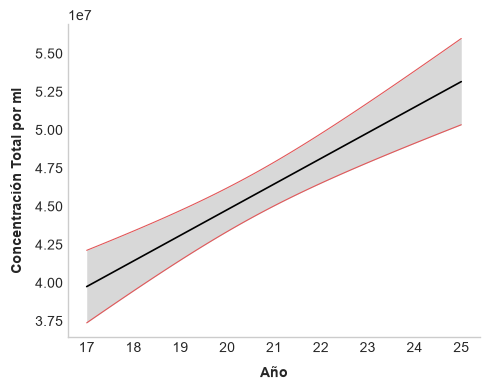

In [8]:
modelo_concentracion = smf.ols(
    'concentracion_por_ml ~ año + edad + dias_abstinencia',
    data=df
).fit(cov_type='HC3')

print(modelo_concentracion.summary())

fig, ax = adjusted_prediction(
    model=modelo_concentracion, 
    data=df, 
    var_name='Concentración Total por ml', color_borde='#E15759'
)

**Resumen General**

El modelo de regresión lineal múltiple para la concentración espermática por mililitro explica el 1.5% de la variabilidad (R² = 0.015), lo que indica que las variables incluidas (año, edad y días de abstinencia) tienen un poder predictivo muy limitado sobre la concentración. El modelo es altamente significativo en su conjunto (p = 1.26e-10). Las tres variables predictoras son significativas: el año y los días de abstinencia tienen un efecto positivo, mientras que la edad tiene un efecto negativo sobre la concentración.

**Evaluación Global del Modelo**

| Estadístico | Valor | Interpretación |
|-------------|-------|----------------|
| R² | 0.015 | Solo el 1.5% de la variabilidad de la concentración es explicada por el modelo |
| R² Ajustado | 0.014 | Prácticamente igual al R², indica que las variables incluidas son relevantes |
| F-estadístico | 16.47 | Modelo significativo en su conjunto |
| p-value (F) | 1.26e-10 | Altamente significativo (p < 0.001) |
| n | 3,385 | Tamaño muestral adecuado |

- El modelo es estadísticamente significativo, pero clínicamente muy débil
- El 98.5% de la variabilidad de la concentración queda sin explicar por estas variables
- Otros factores no incluidos tienen un impacto mucho mayor

**Coeficientes del Modelo**

| Variable | Coeficiente | Error Estándar | z | p-value | IC 95% |
|----------|-------------|----------------|---|---------|--------|
| Intercepto | 17,470,000 | 7,030,000 | 2.487 | 0.013 | [3,700,000, 31,200,000] |
| Año | +1,676,000 | 278,000 | 6.025 | < 0.001 | [1,130,000, 2,220,000] |
| Edad | -280,000 | 102,000 | -2.737 | 0.006 | [-480,000, -79,500] |
| Días de Abstinencia | +1,065,000 | 437,000 | 2.435 | 0.015 | [208,000, 1,920,000] |

**Año (p < 0.001) - Altamente significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +1.676 millones por año |
| p-value | < 0.001 (altamente significativo) |
| IC 95% | [1.13M, 2.22M] (no incluye el cero) |
| Conclusión | La concentración ha aumentado significativamente con el tiempo |

- Por cada año, la concentración aumenta en 1.676 millones/ml
- Este resultado es consistente con el aumento observado en los análisis descriptivos (+18.4%)

**Edad (p = 0.006) - Significativa**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -280,000 por año de edad |
| p-value | 0.006 (significativo) |
| IC 95% | [-480,000, -79,500] (no incluye el cero) |
| Conclusión | La edad tiene un efecto negativo sobre la concentración |

- Por cada año de edad, la concentración disminuye en 280,000/ml
- Un paciente de 40 años tendría, en promedio, 4.2 millones/ml menos que uno de 25 años (15 años × 0.28M = 4.2M)
- Este efecto es biológicamente plausible (disminución de la producción espermática con la edad)

**Días de Abstinencia (p = 0.015) - Significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +1.065 millones por día de abstinencia |
| p-value | 0.015 (significativo) |
| IC 95% | [208,000, 1,920,000] (no incluye el cero) |
| Conclusión | Los días de abstinencia tienen un efecto positivo sobre la concentración |

- Por cada día adicional de abstinencia, la concentración aumenta en 1.065 millones/ml
- Un paciente con 5 días de abstinencia tendría, en promedio, 4.26 millones/ml más que uno con 1 día (4 días × 1.065M = 4.26M)
- Este efecto es biológicamente plausible (mayor acumulación de espermatozoides)

**Evaluación de Supuestos del Modelo**

| Prueba | Estadístico | Valor | Interpretación |
|--------|-------------|-------|----------------|
| Omnibus | 711.95 | p < 0.001 | Los residuos no son normales |
| Jarque-Bera | 1451.03 | p < 0.001 | Los residuos no son normales |
| Skew | 1.238 | - | Asimetría positiva en los residuos |
| Kurtosis | 5.038 | - | Distribución más apuntada que la normal |
| Durbin-Watson | 1.724 | - | No hay autocorrelación (cercano a 2) |

**Interpretación de los supuestos**

| Supuesto | Estado | Interpretación |
|----------|--------|----------------|
| Normalidad de residuos | No se cumple | Los residuos no siguen una distribución normal |
| Homocedasticidad | Manejada | Se usaron errores robustos HC3 |
| Independencia | Cumplida | Durbin-Watson ≈ 1.72 (no autocorrelación) |
| Linealidad | Asumida | No se evaluó formalmente |

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Modelo global | Altamente significativo (p = 1.26e-10) pero muy débil (R² = 0.015) |
| Año | Altamente significativo (p < 0.001) - aumenta la concentración |
| Edad | Significativa (p = 0.006) - disminuye la concentración |
| Días de abstinencia | Significativo (p = 0.015) - aumenta la concentración |
| Poder explicativo | Muy bajo - solo el 1.5% de la variabilidad explicada |

**Conclusión Final**

El modelo de regresión para la concentración espermática por mililitro muestra que el año, la edad y los días de abstinencia son predictores significativos. El año tiene un efecto positivo (+1.676M por año), la edad tiene un efecto negativo (-0.280M por año), y los días de abstinencia tienen un efecto positivo (+1.065M por día). Sin embargo, el poder explicativo del modelo es muy bajo (R² = 0.015), lo que indica que factores no incluidos en el modelo explican la mayor parte de la variabilidad de la concentración. El aumento en la concentración a lo largo del tiempo (+13.4M/ml entre 2017 y 2025) es consistente con los hallazgos descriptivos previos.

## **Modelo de Regresión Lineal Múltiple para la Viabilidad Espermática (Test de Eosina)**

Para evaluar la relación entre el año de estudio y el porcentaje de espermatozoides viables evaluado mediante el test de eosina, controlando por los posibles efectos de confusión de la edad del paciente y los días de abstinencia sexual previa, se ajusta un modelo de regresión lineal múltiple. El modelo incluye como variables predictoras el año de estudio, la edad y los días de abstinencia, y utiliza errores estándar robustos (HC3) para garantizar la validez de las inferencias en presencia de heterocedasticidad. A partir de los coeficientes estimados, se genera una gráfica de predicción ajustada que muestra la tendencia de la viabilidad espermática a lo largo del tiempo, manteniendo la edad y los días de abstinencia en sus valores medios, acompañada de su intervalo de confianza del 95%.

                            OLS Regression Results                            
Dep. Variable:        test_eosina_pct   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     18.69
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           5.31e-12
Time:                        17:10:28   Log-Likelihood:                -12855.
No. Observations:                2815   AIC:                         2.572e+04
Df Residuals:                    2811   BIC:                         2.574e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           92.4710      4.276  

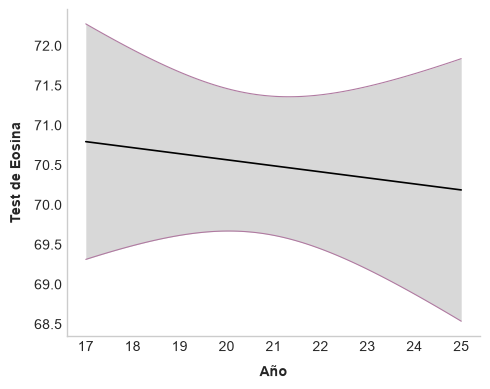

In [9]:
modelo_eosina = smf.ols(
    'test_eosina_pct ~ año + edad + dias_abstinencia',
    data=df
).fit(cov_type='HC3')

print(modelo_eosina.summary())

fig, ax = adjusted_prediction(
    model=modelo_eosina, 
    data=df, 
    var_name='Test de Eosina', color_borde='#B07AA1'
)

**Resumen General**

El modelo de regresión lineal múltiple para la viabilidad espermática (test de eosina) explica el 2.5% de la variabilidad (R² = 0.025), lo que indica que las variables incluidas (año, edad y días de abstinencia) tienen un poder predictivo limitado sobre la viabilidad. El modelo es altamente significativo en su conjunto (p = 5.31e-12). Solo la edad es un predictor significativo (p < 0.001), con un efecto negativo sobre la viabilidad. El año (p = 0.648) y los días de abstinencia (p = 0.203) no son significativos.

**Evaluación Global del Modelo**

| Estadístico | Valor | Interpretación |
|-------------|-------|----------------|
| R² | 0.025 | Solo el 2.5% de la variabilidad de la viabilidad es explicada por el modelo |
| R² Ajustado | 0.024 | Prácticamente igual al R², indica que las variables incluidas son relevantes |
| F-estadístico | 18.69 | Modelo significativo en su conjunto |
| p-value (F) | 5.31e-12 | Altamente significativo (p < 0.001) |
| n | 2,815 | Tamaño muestral adecuado |

- El modelo es estadísticamente significativo, pero clínicamente débil
- El 97.5% de la variabilidad de la viabilidad queda sin explicar por estas variables
- La edad es el principal factor explicativo dentro del modelo

**Coeficientes del Modelo**

| Variable | Coeficiente | Error Estándar | z | p-value | IC 95% |
|----------|-------------|----------------|---|---------|--------|
| Intercepto | 92.47 | 4.276 | 21.625 | < 0.001 | [84.09, 100.85] |
| Año | -0.0759 | 0.166 | -0.457 | 0.648 | [-0.401, 0.250] |
| Edad | -0.5049 | 0.069 | -7.297 | < 0.001 | [-0.641, -0.369] |
| Días de Abstinencia | -0.3407 | 0.268 | -1.273 | 0.203 | [-0.865, 0.184] |

**Año (p = 0.648) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.076 puntos porcentuales por año |
| p-value | 0.648 (no significativo) |
| IC 95% | [-0.401, 0.250] (incluye el cero) |
| Conclusión | No hay evidencia de que la viabilidad haya cambiado con el tiempo |

- La viabilidad no ha mostrado una tendencia significativa a lo largo del tiempo
- Este resultado es consistente con los análisis previos que no encontraron diferencias entre períodos

**Edad (p < 0.001) - Altamente significativa**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.505 puntos porcentuales por año de edad |
| p-value | < 0.001 (altamente significativo) |
| IC 95% | [-0.641, -0.369] (no incluye el cero) |
| Conclusión | La edad tiene un efecto negativo sobre la viabilidad |

- Por cada año de edad, la viabilidad disminuye en 0.505 puntos porcentuales
- Un paciente de 40 años tendría, en promedio, 7.6 puntos porcentuales menos de viabilidad que uno de 25 años (15 años × 0.505 = 7.6)
- Este es el efecto más fuerte entre todos los predictores analizados

**Días de Abstinencia (p = 0.203) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.341 puntos porcentuales por día |
| p-value | 0.203 (no significativo) |
| IC 95% | [-0.865, 0.184] (incluye el cero) |
| Conclusión | No hay evidencia de que los días de abstinencia afecten la viabilidad |

- Los días de abstinencia no tienen un efecto significativo sobre la viabilidad
- Esto es biológicamente plausible, la viabilidad depende más de la integridad de la membrana que de la cantidad de espermatozoides

**Evaluación de Supuestos del Modelo**

| Prueba | Estadístico | Valor | Interpretación |
|--------|-------------|-------|----------------|
| Omnibus | 937.97 | p < 0.001 | Los residuos no son normales |
| Jarque-Bera | 2505.86 | p < 0.001 | Los residuos no son normales |
| Skew | -1.804 | - | Fuerte asimetría negativa en los residuos |
| Kurtosis | 5.889 | - | Distribución más apuntada que la normal |
| Durbin-Watson | 1.819 | - | No hay autocorrelación (cercano a 2) |

**Interpretación de los supuestos**

| Supuesto | Estado | Interpretación |
|----------|--------|----------------|
| Normalidad de residuos | No se cumple | Los residuos no siguen una distribución normal |
| Homocedasticidad | Manejada | Se usaron errores robustos HC3 |
| Independencia | Cumplida | Durbin-Watson ≈ 1.82 (no autocorrelación) |
| Linealidad | Asumida | No se evaluó formalmente |

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Modelo global | Altamente significativo (p = 5.31e-12) pero débil (R² = 0.025) |
| Año | No significativo (p = 0.648) |
| Edad | Altamente significativa (p < 0.001) - disminuye la viabilidad |
| Días de abstinencia | No significativo (p = 0.203) |
| Poder explicativo | Muy bajo - solo el 2.5% de la variabilidad explicada |

**Conclusión Final**

El modelo de regresión para la viabilidad espermática muestra que la edad es el único predictor significativo, con un efecto negativo de -0.505 puntos porcentuales por año de edad. El año (p = 0.648) y los días de abstinencia (p = 0.203) no son predictores significativos. El modelo explica solo el 2.5% de la variabilidad (R² = 0.025), lo que indica que factores no incluidos explican la mayor parte de la variabilidad de la viabilidad. La viabilidad es un parámetro estable que no ha cambiado con el tiempo, a diferencia de la concentración y el recuento total.

## **Modelo de Regresión Lineal Múltiple para la Motilidad Progresiva**

Para evaluar la relación entre el año de estudio y el porcentaje de espermatozoides con motilidad progresiva, controlando por los posibles efectos de confusión de la edad del paciente y los días de abstinencia sexual previa, se ajusta un modelo de regresión lineal múltiple. El modelo incluye como variables predictoras el año de estudio, la edad y los días de abstinencia, y utiliza errores estándar robustos (HC3) para garantizar la validez de las inferencias en presencia de heterocedasticidad. A partir de los coeficientes estimados, se genera una gráfica de predicción ajustada que muestra la tendencia de la motilidad progresiva a lo largo del tiempo, manteniendo la edad y los días de abstinencia en sus valores medios, acompañada de su intervalo de confianza del 95%.

                               OLS Regression Results                               
Dep. Variable:     motilidad_progresiva_pct   R-squared:                       0.025
Model:                                  OLS   Adj. R-squared:                  0.024
Method:                       Least Squares   F-statistic:                     28.45
Date:                      Fri, 31 Jul 2026   Prob (F-statistic):           3.69e-18
Time:                              17:10:29   Log-Likelihood:                -14946.
No. Observations:                      3384   AIC:                         2.990e+04
Df Residuals:                          3380   BIC:                         2.992e+04
Df Model:                                 3                                         
Covariance Type:                        HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

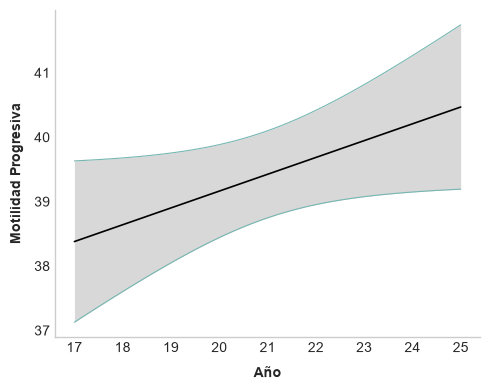

In [10]:
modelo_progresiva = smf.ols(
    'motilidad_progresiva_pct ~ año + edad + dias_abstinencia',
    data=df
).fit(cov_type='HC3')

print(modelo_progresiva.summary())

fig, ax = adjusted_prediction(
    model=modelo_progresiva, 
    data=df, 
    var_name='Motilidad Progresiva', color_borde='#76B7B2'
)

**Resumen General**

El modelo de regresión lineal múltiple para la motilidad progresiva explica el 2.5% de la variabilidad (R² = 0.025), lo que indica que las variables incluidas (año, edad y días de abstinencia) tienen un poder predictivo limitado sobre la motilidad progresiva. El modelo es altamente significativo en su conjunto (p = 3.69e-18). Solo la edad es un predictor altamente significativo (p < 0.001), con un efecto negativo sobre la motilidad progresiva. El año muestra una tendencia marginal (p = 0.055), mientras que los días de abstinencia no son significativos (p = 0.586).

**Evaluación Global del Modelo**

| Estadístico | Valor | Interpretación |
|-------------|-------|----------------|
| R² | 0.025 | Solo el 2.5% de la variabilidad de la motilidad progresiva es explicada por el modelo |
| R² Ajustado | 0.024 | Prácticamente igual al R², indica que las variables incluidas son relevantes |
| F-estadístico | 28.45 | Modelo significativo en su conjunto |
| p-value (F) | 3.69e-18 | Altamente significativo (p < 0.001) |
| n | 3,384 | Tamaño muestral adecuado |

- El modelo es estadísticamente significativo, pero clínicamente débil
- El 97.5% de la variabilidad de la motilidad progresiva queda sin explicar por estas variables
- La edad es el principal factor explicativo dentro del modelo

**Coeficientes del Modelo**

| Variable | Coeficiente | Error Estándar | z | p-value | IC 95% |
|----------|-------------|----------------|---|---------|--------|
| Intercepto | 49.89 | 3.305 | 15.098 | < 0.001 | [43.42, 56.37] |
| Año | 0.2610 | 0.136 | 1.917 | 0.055 | [-0.006, 0.528] |
| Edad | -0.4317 | 0.047 | -9.133 | < 0.001 | [-0.524, -0.339] |
| Días de Abstinencia | 0.0743 | 0.136 | 0.545 | 0.586 | [-0.193, 0.342] |

**Año (p = 0.055) - Tendencia marginal**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.261 puntos porcentuales por año |
| p-value | 0.055 (marginalmente no significativo) |
| IC 95% | [-0.006, 0.528] (apenas incluye el cero) |
| Conclusión | Tendencia marginal a aumentar, pero no alcanza significancia estadística |

- Hay una tendencia positiva en la motilidad progresiva a lo largo del tiempo
- El IC 95% incluye el cero, por lo que no podemos afirmar con certeza que haya un aumento real
- Este resultado es consistente con la estabilidad observada en los análisis descriptivos

**Edad (p < 0.001) - Altamente significativa**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.431 puntos porcentuales por año de edad |
| p-value | < 0.001 (altamente significativo) |
| IC 95% | [-0.524, -0.339] (no incluye el cero) |
| Conclusión | La edad tiene un efecto negativo sobre la motilidad progresiva |

- Por cada año de edad, la motilidad progresiva disminuye en 0.431 puntos porcentuales
- Un paciente de 40 años tendría, en promedio, 6.4 puntos porcentuales menos de motilidad progresiva que uno de 25 años (15 años × 0.431 = 6.4)
- Este es el efecto más fuerte entre todos los predictores analizados para la motilidad

**Días de Abstinencia (p = 0.586) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.074 puntos porcentuales por día |
| p-value | 0.586 (no significativo) |
| IC 95% | [-0.193, 0.342] (incluye el cero) |
| Conclusión | No hay evidencia de que los días de abstinencia afecten la motilidad progresiva |

- Los días de abstinencia no tienen un efecto significativo sobre la motilidad progresiva
- Esto es biológicamente consistente, la motilidad depende más de la calidad del espermatozoide que de la cantidad

**Evaluación de Supuestos del Modelo**

| Prueba | Estadístico | Valor | Interpretación |
|--------|-------------|-------|----------------|
| Omnibus | 293.30 | p < 0.001 | Los residuos no son normales |
| Jarque-Bera | 199.18 | p < 0.001 | Los residuos no son normales |
| Skew | -0.481 | - | Asimetría negativa leve en los residuos |
| Kurtosis | 2.302 | - | Cercano a la normal (3.0) |
| Durbin-Watson | 1.740 | - | No hay autocorrelación (muy cercano a 2) |

**Interpretación de los supuestos**

| Supuesto | Estado | Interpretación |
|----------|--------|----------------|
| Normalidad de residuos | No se cumple | Los residuos no siguen una distribución normal |
| Homocedasticidad | Manejada | Se usaron errores robustos HC3 |
| Independencia | Cumplida | Durbin-Watson = 1.74 (excelente) |
| Linealidad | Asumida | No se evaluó formalmente |

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Modelo global | Altamente significativo (p = 3.69e-18) pero débil (R² = 0.025) |
| Año | Tendencia marginal (p = 0.055) - límite de la significancia |
| Edad | Altamente significativa (p < 0.001) - disminuye la motilidad |
| Días de abstinencia | No significativo (p = 0.586) |
| Poder explicativo | Muy bajo - solo el 2.5% de la variabilidad explicada |

**Conclusión Final**

El modelo de regresión para la motilidad progresiva muestra que la edad es el predictor más fuerte, con un efecto negativo de -0.429 puntos porcentuales por año de edad. El año muestra una tendencia marginal positiva (p = 0.055) que no alcanza significancia estadística, mientras que los días de abstinencia no son significativos (p = 0.586). El modelo explica solo el 2.5% de la variabilidad (R² = 0.025), lo que indica que factores no incluidos en el modelo explican la mayor parte de la variabilidad de la motilidad progresiva. La motilidad progresiva parece estable en el tiempo, con una tendencia positiva que no es estadísticamente concluyente.

## **Modelo de Regresión Lineal Múltiple para la Motilidad Total**

Para evaluar la relación entre el año de estudio y el porcentaje de motilidad total (progresiva + no progresiva), controlando por los posibles efectos de confusión de la edad del paciente y los días de abstinencia sexual previa, se ajusta un modelo de regresión lineal múltiple. El modelo incluye como variables predictoras el año de estudio, la edad y los días de abstinencia, y utiliza errores estándar robustos (HC3) para garantizar la validez de las inferencias en presencia de heterocedasticidad. A partir de los coeficientes estimados, se genera una gráfica de predicción ajustada que muestra la tendencia de la motilidad total a lo largo del tiempo, manteniendo la edad y los días de abstinencia en sus valores medios, acompañada de su intervalo de confianza del 95%.

                             OLS Regression Results                            
Dep. Variable:     motilidad_total_pct   R-squared:                       0.024
Model:                             OLS   Adj. R-squared:                  0.024
Method:                  Least Squares   F-statistic:                     26.35
Date:                 Fri, 31 Jul 2026   Prob (F-statistic):           7.68e-17
Time:                         17:10:29   Log-Likelihood:                -15569.
No. Observations:                 3384   AIC:                         3.115e+04
Df Residuals:                     3380   BIC:                         3.117e+04
Df Model:                            3                                         
Covariance Type:                   HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           74.9432   

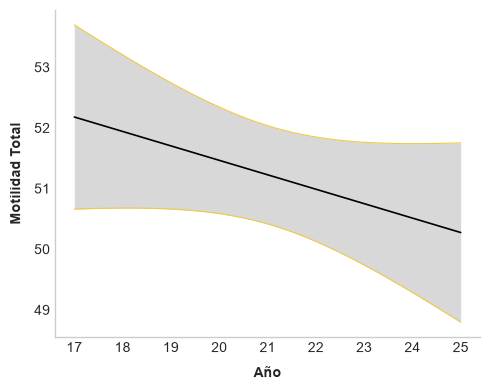

In [11]:
modelo_total = smf.ols(
    'motilidad_total_pct ~ año + edad + dias_abstinencia',
    data=df
).fit(cov_type='HC3')

print(modelo_total.summary())

fig, ax = adjusted_prediction(
    model=modelo_total, 
    data=df, 
    var_name='Motilidad Total', color_borde='#EDC948'
)

**Resumen General**

El modelo de regresión lineal múltiple para la motilidad total explica el 2.4% de la variabilidad (R² = 0.024), lo que indica que las variables incluidas (año, edad y días de abstinencia) tienen un poder predictivo limitado sobre la motilidad total. El modelo es altamente significativo en su conjunto (p = 7.68e-17). Solo la edad es un predictor altamente significativo (p < 0.001), con un efecto negativo sobre la motilidad total. El año (p = 0.139) y los días de abstinencia (p = 0.820) no son significativos.

**Evaluación Global del Modelo**

| Estadístico | Valor | Interpretación |
|-------------|-------|----------------|
| R² | 0.024 | Solo el 2.4% de la variabilidad de la motilidad total es explicada por el modelo |
| R² Ajustado | 0.024 | Prácticamente igual al R², indica que las variables incluidas son relevantes |
| F-estadístico | 26.35 | Modelo significativo en su conjunto |
| p-value (F) | 7.68e-17 | Altamente significativo (p < 0.001) |
| n | 3,384 | Tamaño muestral adecuado |

- El modelo es estadísticamente significativo, pero clínicamente débil
- El 97.6% de la variabilidad de la motilidad total queda sin explicar por estas variables
- La edad es el principal factor explicativo dentro del modelo

**Coeficientes del Modelo**

| Variable | Coeficiente | Error Estándar | z | p-value | IC 95% |
|----------|-------------|----------------|---|---------|--------|
| Intercepto | 74.94 | 3.928 | 19.078 | < 0.001 | [67.24, 82.64] |
| Año | -0.2381 | 0.161 | -1.480 | 0.139 | [-0.553, 0.077] |
| Edad | -0.5013 | 0.058 | -8.623 | < 0.001 | [-0.615, -0.387] |
| Días de Abstinencia | 0.0386 | 0.169 | 0.228 | 0.820 | [-0.293, 0.370] |

**Año (p = 0.139) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.238 puntos porcentuales por año |
| p-value | 0.139 (no significativo) |
| IC 95% | [-0.553, 0.077] (incluye el cero) |
| Conclusión | No hay evidencia de que la motilidad total haya cambiado con el tiempo |

- La motilidad total no ha mostrado una tendencia significativa a lo largo del tiempo
- Aunque la estimación puntual sugiere una ligera disminución, no es estadísticamente concluyente

**Edad (p < 0.001) - Altamente significativa**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.501 puntos porcentuales por año de edad |
| p-value | < 0.001 (altamente significativo) |
| IC 95% | [-0.615, -0.387] (no incluye el cero) |
| Conclusión | La edad tiene un efecto negativo sobre la motilidad total |

- Por cada año de edad, la motilidad total disminuye en 0.501 puntos porcentuales
- Un paciente de 40 años tendría, en promedio, 7.5 puntos porcentuales menos de motilidad total que uno de 25 años (15 años × 0.501 = 7.5)
- Este es el efecto más fuerte entre todos los predictores analizados

**Días de Abstinencia (p = 0.820) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.039 puntos porcentuales por día |
| p-value | 0.820 (no significativo) |
| IC 95% | [-0.293, 0.370] (incluye el cero) |
| Conclusión | No hay evidencia de que los días de abstinencia afecten la motilidad total |

- Los días de abstinencia no tienen un efecto significativo sobre la motilidad total
- Esto es consistente con los hallazgos para la motilidad progresiva

**Evaluación de Supuestos del Modelo**

| Prueba | Estadístico | Valor | Interpretación |
|--------|-------------|-------|----------------|
| Omnibus | 313.70 | p < 0.001 | Los residuos no son normales |
| Jarque-Bera | 305.47 | p < 0.001 | Los residuos no son normales |
| Skew | -0.676 | - | Asimetría negativa en los residuos |
| Kurtosis | 2.419 | - | Cercano a la normal (3.0) |
| Durbin-Watson | 1.744 | - | No hay autocorrelación (cercano a 2) |

**Interpretación de los supuestos**

| Supuesto | Estado | Interpretación |
|----------|--------|----------------|
| Normalidad de residuos | No se cumple | Los residuos no siguen una distribución normal |
| Homocedasticidad | Manejada | Se usaron errores robustos HC3 |
| Independencia | Cumplida | Durbin-Watson ≈ 1.74 (no autocorrelación) |
| Linealidad | Asumida | No se evaluó formalmente |

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Modelo global | Altamente significativo (p = 7.68e-17) pero débil (R² = 0.024) |
| Año | No significativo (p = 0.139) |
| Edad | Altamente significativa (p < 0.001) - disminuye la motilidad |
| Días de abstinencia | No significativo (p = 0.820) |
| Poder explicativo | Muy bajo - solo el 2.4% de la variabilidad explicada |

**Conclusión Final**

El modelo de regresión para la motilidad total muestra que la edad es el único predictor significativo, con un efecto negativo de -0.501 puntos porcentuales por año de edad. El año (p = 0.139) y los días de abstinencia (p = 0.820) no son predictores significativos. El modelo explica solo el 2.4% de la variabilidad (R² = 0.024), lo que indica que factores no incluidos en el modelo explican la mayor parte de la variabilidad de la motilidad total. La motilidad total es un parámetro estable que no ha cambiado significativamente con el tiempo.

## **Modelo de Regresión Lineal Múltiple para el Porcentaje de Espermatozoides Normales**

Para evaluar la relación entre el año de estudio y el porcentaje de espermatozoides con morfología normal, controlando por los posibles efectos de confusión de la edad del paciente y los días de abstinencia sexual previa, se ajusta un modelo de regresión lineal múltiple. El modelo incluye como variables predictoras el año de estudio, la edad y los días de abstinencia, y utiliza errores estándar robustos (HC3) para garantizar la validez de las inferencias en presencia de heterocedasticidad. A partir de los coeficientes estimados, se genera una gráfica de predicción ajustada que muestra la tendencia del porcentaje de espermatozoides normales a lo largo del tiempo, manteniendo la edad y los días de abstinencia en sus valores medios, acompañada de su intervalo de confianza del 95%.

                                 OLS Regression Results                                 
Dep. Variable:     espermatozoides_normales_pct   R-squared:                       0.005
Model:                                      OLS   Adj. R-squared:                  0.004
Method:                           Least Squares   F-statistic:                     5.008
Date:                          Fri, 31 Jul 2026   Prob (F-statistic):            0.00183
Time:                                  17:10:29   Log-Likelihood:                -8099.7
No. Observations:                          2782   AIC:                         1.621e+04
Df Residuals:                              2778   BIC:                         1.623e+04
Df Model:                                     3                                         
Covariance Type:                            HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

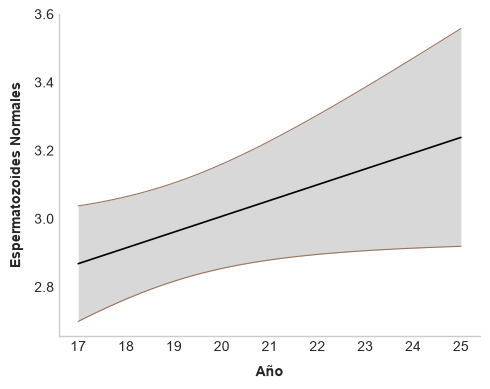

In [12]:
modelo_normales = smf.ols(
    'espermatozoides_normales_pct ~ año + edad + dias_abstinencia',
    data=df
).fit(cov_type='HC3')

print(modelo_normales.summary())

fig, ax = adjusted_prediction(
    model=modelo_normales, 
    data=df, 
    var_name='Espermatozoides Normales', color_borde='#9C755F'
)

**Resumen General**

El modelo de regresión lineal múltiple para el porcentaje de espermatozoides normales explica solo el 0.5% de la variabilidad (R² = 0.005), lo que indica que las variables incluidas (año, edad y días de abstinencia) tienen un poder predictivo prácticamente nulo sobre la morfología normal. El modelo es significativo en su conjunto (p = 0.00183), pero muy débil. La edad es el predictor más significativo (p = 0.001), con un efecto negativo; el año muestra una tendencia marginal (p = 0.052), mientras que los días de abstinencia no son significativos (p = 0.286).

**Evaluación Global del Modelo**

| Estadístico | Valor | Interpretación |
|-------------|-------|----------------|
| R² | 0.005 | Solo el 0.5% de la variabilidad de la morfología normal es explicada por el modelo |
| R² Ajustado | 0.004 | Prácticamente igual al R² |
| F-estadístico | 5.008 | Modelo significativo en su conjunto |
| p-value (F) | 0.00183 | Significativo (p < 0.01) |
| n | 2,782 | Tamaño muestral adecuado |

- El modelo es estadísticamente significativo, pero clínicamente muy débil
- El 99.5% de la variabilidad de la morfología queda sin explicar
- La morfología es difícil de predecir con estas variables

**Coeficientes del Modelo**

| Variable | Coeficiente | Error Estándar | z | p-value | IC 95% |
|----------|-------------|----------------|---|---------|--------|
| Intercepto | 3.45 | 0.683 | 5.055 | < 0.001 | [2.11, 4.79] |
| Año | 0.0463 | 0.024 | 1.940 | 0.052 | [-0.000, 0.093] |
| Edad | -0.0397 | 0.012 | -3.192 | 0.001 | [-0.064, -0.015] |
| Días de Abstinencia | 0.0306 | 0.029 | 1.066 | 0.286 | [-0.026, 0.087] |

**Año (p = 0.052) Tendencia marginal**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.046 puntos porcentuales por año |
| p-value | 0.052 (marginalmente no significativo) |
| IC 95% | [-0.000, 0.093] (apenas incluye el cero) |
| Conclusión | Tendencia marginal a aumentar, pero no alcanza significancia |

- Hay una tendencia positiva en la morfología normal a lo largo del tiempo
- El IC 95% incluye el cero, por lo que no podemos afirmar con certeza que haya un aumento real
- Este resultado es consistente con la estabilidad observada en análisis previos

**Edad (p = 0.001) Significativa**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | -0.040 puntos porcentuales por año de edad |
| p-value | 0.001 (significativo) |
| IC 95% | [-0.064, -0.015] (no incluye el cero) |
| Conclusión | La edad tiene un efecto negativo sobre la morfología normal |

- Por cada año de edad, la morfología normal disminuye en 0.040 puntos porcentuales
- Un paciente de 40 años tendría, en promedio, 0.60 puntos porcentuales menos de formas normales que uno de 25 años (15 años × 0.040 = 0.60)
- Este efecto es pequeño pero estadísticamente significativo

**Días de Abstinencia (p = 0.286) - No significativo**

| Aspecto | Interpretación |
|---------|----------------|
| Coeficiente | +0.031 puntos porcentuales por día |
| p-value | 0.286 (no significativo) |
| IC 95% | [-0.026, 0.087] (incluye el cero) |
| Conclusión | No hay evidencia de que los días de abstinencia afecten la morfología |

- Los días de abstinencia no tienen un efecto significativo sobre la morfología
- Esto es biológicamente plausible: la morfología está determinada por factores genéticos y ambientales, no por la abstinencia

**Evaluación de Supuestos del Modelo**

| Prueba | Estadístico | Valor | Interpretación |
|--------|-------------|-------|----------------|
| Omnibus | 5,238.05 | p < 0.001 | Los residuos no son normales |
| Jarque-Bera | 9,395,806.62 | p < 0.001 | Los residuos no son normales |
| Skew | 14.05 | - | Sesgo extremadamente positivo |
| Kurtosis | 286.31 | - | Curtosis extremadamente alta |
| Durbin-Watson | 1.936 | - | No hay autocorrelación (cercano a 2) |

**Interpretación de los supuestos**

| Supuesto | Estado | Interpretación |
|----------|--------|----------------|
| Normalidad de residuos | No se cumple | Los residuos no siguen una distribución normal |
| Homocedasticidad | Manejada | Se usaron errores robustos HC3 |
| Independencia | Cumplida | Durbin-Watson = 1.94 (cercano a 2) |
| Linealidad | Asumida | No se evaluó formalmente |

- El Durbin-Watson = 1.94 no sugiere autocorrelación preocupante

**Resumen de Hallazgos Clave**

| Aspecto | Conclusión |
|---------|------------|
| Modelo global | Significativo (p = 0.00183) pero muy débil (R² = 0.005) |
| Año | Tendencia marginal (p = 0.052) - límite de la significancia |
| Edad | Significativa (p = 0.001) - disminuye la morfología |
| Días de abstinencia | No significativo (p = 0.286) |
| Poder explicativo | Prácticamente nulo - solo el 0.5% de la variabilidad explicada |

**Conclusión Final**

El modelo de regresión para la morfología normal es muy débil (R² = 0.005). La edad muestra un efecto negativo pequeño pero significativo (-0.040% por año), mientras que el año muestra una tendencia marginal positiva (p = 0.052) que no alcanza significancia estadística. Los días de abstinencia no son significativos (p = 0.286). El modelo explica solo el 0.5% de la variabilidad, lo que indica que factores genéticos, ambientales y otros no incluidos son los principales determinantes de la morfología espermática. La morfología normal es el parámetro más difícil de predecir con las variables incluidas en este modelo.